# Advanced AI and Uncertainty: Live Demo (Presentation 1)

**Course:** CS405 &nbsp;|&nbsp; **Team:** Team 01 &nbsp;|&nbsp; **Presenter and Team Leader:** Ahmed Ayman Tayel (registration ID 232611000001)

**Dataset (public, real):** Pima Indians Diabetes Database. 768 women aged 21 or older of Pima Indian heritage, 8 clinical measurements and a diabetes outcome (1 = diabetes, 0 = no diabetes).
Originally collected by the U.S. National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK) and described in
J. W. Smith, J. E. Everhart, W. C. Dickson, W. C. Knowler and R. S. Johannes, "Using the ADAP learning algorithm to forecast the onset of diabetes mellitus," *Proc. Symp. Computer Applications in Medical Care*, 1988, pp. 261-265.
CSV copy used here: `plotly/datasets` on GitHub (`diabetes.csv`), with the `npradaschnor/Pima-Indians-Diabetes-Dataset` copy as a fallback.

**How to run:** Runtime > Run all. It needs no installs and takes about 30 seconds. Random seeds are fixed, so every run gives the same numbers and figures.

| Part | What it shows | Slide |
| --- | --- | --- |
| A | Count and visualise missing values, including a hidden form (zeros that cannot be real) | 21, 22, 25 |
| B | One variable (BMI) with a crisp threshold and a fuzzy membership function, side by side | 15, 25 |
| C | The same simple model fitted on 20, 200 and 2,000 samples: spread shrinks (epistemic), noise stays (aleatoric) | 12, 13 |

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(405)      # fixed seed: same numbers and figures on every run
os.makedirs("figures", exist_ok=True)  # PNGs for the slides are saved here

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 12, "axes.titlesize": 13,
    "axes.spines.top": False, "axes.spines.right": False,
})

# colour tokens, identical to the slide design
CRISP, FUZZY, PROB = "#374151", "#0072B2", "#009E73"
WARM, HOT = "#E69F00", "#D55E00"
ALEA, EPIS, MISS = "#56B4E9", "#CC79A7", "#9CA3AF"

In [2]:
URLS = [
    "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv",
    "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv",
]
for url in URLS:
    try:
        df = pd.read_csv(url)
        print("Loaded from:", url)
        break
    except Exception as err:
        print("Could not load", url, "->", err)
else:
    raise RuntimeError("The dataset could not be downloaded. Check the internet connection.")

assert df.shape == (768, 9), df.shape
print("Dataset: Pima Indians Diabetes Database (NIDDK; Smith et al., 1988):",
      df.shape[0], "patients,", df.shape[1] - 1, "predictors + Outcome")
df.head()

Loaded from: https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv
Dataset: Pima Indians Diabetes Database (NIDDK; Smith et al., 1988): 768 patients, 8 predictors + Outcome


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Part A. Missing data: the visible count and the hidden count

A quick check says the table is complete. Then we ask a domain question: can a living patient really have a BMI, a blood pressure or a glucose of exactly 0?

In [3]:
# 1) The naive check: no cell is marked missing.
print("Cells marked missing (NaN):", int(df.isna().sum().sum()))

Cells marked missing (NaN): 0


In [4]:
# 2) The hidden form: zeros that cannot be real measurements.
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
zeros = (df[cols] == 0).sum()
print(zeros.to_string())
print("\nRows with at least one impossible zero:", int((df[cols] == 0).any(axis=1).sum()), "of", len(df))
print("Pregnancies == 0 is legitimate (", int((df['Pregnancies'] == 0).sum()), "patients), so it is NOT recoded.")

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11

Rows with at least one impossible zero: 376 of 768
Pregnancies == 0 is legitimate ( 111 patients), so it is NOT recoded.


In [5]:
# 3) Recode the impossible zeros as real missing values, then count and draw them.
df[cols] = df[cols].replace(0, np.nan)   # hidden zeros -> missing
df[cols].isna().sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

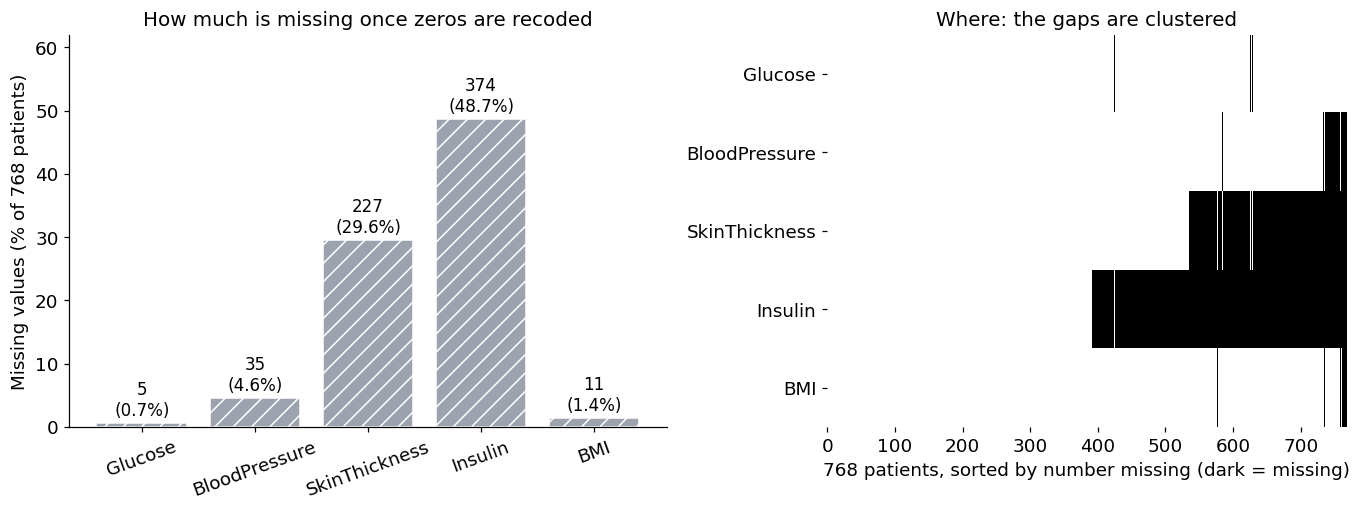

In [6]:
missing = df[cols].isna().sum()
pct = 100 * missing / len(df)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), gridspec_kw={"width_ratios": [1.15, 1]})

bars = axes[0].bar(cols, pct, color=MISS, hatch="//", edgecolor="white")
for b, m, p in zip(bars, missing, pct):
    axes[0].text(b.get_x() + b.get_width() / 2, p + 1.2, f"{m}\n({p:.1f}%)", ha="center", fontsize=11)
axes[0].set_ylim(0, 62)
axes[0].set_ylabel("Missing values (% of 768 patients)")
axes[0].set_title("How much is missing once zeros are recoded")
axes[0].tick_params(axis="x", rotation=20)

order = df[cols].isna().sum(axis=1).sort_values(kind="stable").index
axes[1].imshow(df.loc[order, cols].isna().to_numpy().T, aspect="auto", cmap="Greys", interpolation="nearest")
axes[1].set_yticks(range(len(cols)))
axes[1].set_yticklabels(cols)
axes[1].set_xlabel("768 patients, sorted by number missing (dark = missing)")
axes[1].set_title("Where: the gaps are clustered")
axes[1].spines[["left", "bottom"]].set_visible(False)

plt.tight_layout()
plt.savefig("figures/fig_missing_values.png", dpi=200, bbox_inches="tight")
plt.show()

**Reading the figure.** Almost half of the Insulin values and nearly a third of SkinThickness were recorded as 0, which most plausibly means "not measured".
The dark bands show that the gaps are clustered rather than scattered: the patients who lack SkinThickness usually lack Insulin too.
Clustered gaps are a warning sign that the mechanism may not be MCAR; they are not a proof (see slide 21).

In [7]:
# Does missingness relate to the outcome? (A hint about MAR vs MNAR, never a proof.)
rate = (df[cols].isna().groupby(df["Outcome"]).mean() * 100).round(1)
rate.index = ["Outcome 0 (no diabetes)", "Outcome 1 (diabetes)"]
print("Percent missing by outcome group:")
print(rate.to_string())

Percent missing by outcome group:
                         Glucose  BloodPressure  SkinThickness  Insulin  BMI
Outcome 0 (no diabetes)      0.6            3.8           27.8     47.2  1.8
Outcome 1 (diabetes)         0.7            6.0           32.8     51.5  0.7


The observed data alone cannot prove whether the gaps are MAR or MNAR: proving MNAR would need the very values that are missing.
This is why the choice of a strategy always comes with an assumption that must be stated.

In [8]:
# Three common strategies for Insulin, and the price each one pays.
ins = df["Insulin"]
complete_rows = df.dropna(subset=cols)

table = pd.DataFrame({
    "rows kept": [len(complete_rows), int(ins.notna().sum()), len(ins), len(ins)],
    "mean Insulin": [complete_rows["Insulin"].mean(), ins.mean(),
                     ins.fillna(ins.mean()).mean(), ins.fillna(ins.median()).mean()],
    "sd Insulin": [complete_rows["Insulin"].std(), ins.std(),
                   ins.fillna(ins.mean()).std(), ins.fillna(ins.median()).std()],
}, index=["delete rows with any missing value", "delete only rows missing Insulin",
          "mean imputation", "median imputation"]).round(1)
print(table.to_string())

df["Insulin_missing"] = ins.isna().astype(int)   # missing-value indicator
print("\nIndicator column 'Insulin_missing' flags", int(df["Insulin_missing"].sum()), "patients.")
print("Deleting all incomplete rows keeps", len(complete_rows), "of 768 patients (",
      round(100 * len(complete_rows) / 768, 1), "% ).")
print("Mean imputation shrinks the spread of Insulin from",
      round(ins.std(), 1), "to", round(ins.fillna(ins.mean()).std(), 1), ".")

                                    rows kept  mean Insulin  sd Insulin
delete rows with any missing value        392         156.1       118.8
delete only rows missing Insulin          394         155.5       118.8
mean imputation                           768         155.5        85.0
median imputation                         768         140.7        86.4

Indicator column 'Insulin_missing' flags 374 patients.
Deleting all incomplete rows keeps 392 of 768 patients ( 51.0 % ).
Mean imputation shrinks the spread of Insulin from 118.8 to 85.0 .


## Part B. One variable, two definitions of "obese"

**Crisp:** a patient is obese if BMI is at least 30 (the standard WHO cut-off). **Fuzzy:** membership rises smoothly from 0 at BMI 27 to 1 at BMI 33, so BMI 30 has membership 0.5.
This is a membership *degree*, not a probability.

In [9]:
bmi = np.linspace(15, 60, 451)
crisp = (bmi >= 30).astype(float)      # 0 or 1
fuzzy = np.clip((bmi - 27) / 6, 0, 1)  # 0 ... 1

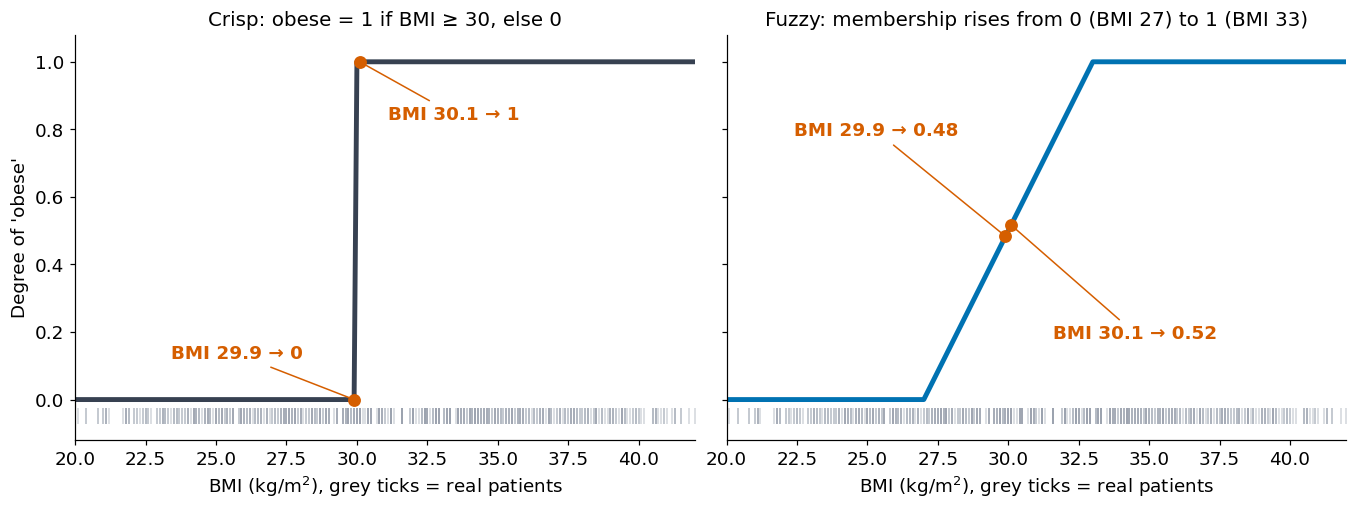

BMI 29.9: crisp = 0, fuzzy = 0.48
BMI 30.1: crisp = 1, fuzzy = 0.52
32.2% of the 757 patients with a recorded BMI fall inside the fuzzy ramp (27 to 33).


In [10]:
patients = df["BMI"].dropna().to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharey=True)

for ax, curve, colour, title in [
    (axes[0], crisp, CRISP, "Crisp: obese = 1 if BMI ≥ 30, else 0"),
    (axes[1], fuzzy, FUZZY, "Fuzzy: membership rises from 0 (BMI 27) to 1 (BMI 33)"),
]:
    ax.plot(bmi, curve, color=colour, lw=3.2)
    ax.plot(patients, np.full_like(patients, -0.05), "|", color=MISS, alpha=0.45, ms=10)  # real patients
    ax.set_xlim(20, 42)
    ax.set_ylim(-0.12, 1.08)
    ax.set_xlabel("BMI (kg/m$^2$), grey ticks = real patients")
    ax.set_title(title)
axes[0].set_ylabel("Degree of 'obese'")

for b, dy in [(29.9, 0.22), (30.1, -0.22)]:
    c = float(b >= 30)
    f = float(np.clip((b - 27) / 6, 0, 1))
    axes[0].scatter([b], [c], color=HOT, zorder=5, s=55)
    axes[1].scatter([b], [f], color=HOT, zorder=5, s=55)
    axes[0].annotate(f"BMI {b} → {c:.0f}", (b, c), xytext=(b - 6.5 if b < 30 else b + 1.0, 0.12 if b < 30 else 0.83),
                     arrowprops=dict(arrowstyle="-", color=HOT), color=HOT, fontsize=12, fontweight="bold")
    axes[1].annotate(f"BMI {b} → {f:.2f}", (b, f), xytext=(b - 7.5 if b < 30 else b + 1.5, 0.78 if b < 30 else 0.18),
                     arrowprops=dict(arrowstyle="-", color=HOT), color=HOT, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("figures/fig_bmi_crisp_vs_fuzzy.png", dpi=200, bbox_inches="tight")
plt.show()

for b in (29.9, 30.1):
    print(f"BMI {b}: crisp = {float(b >= 30):.0f}, fuzzy = {np.clip((b - 27) / 6, 0, 1):.2f}")
share = ((patients > 27) & (patients < 33)).mean() * 100
print(f"{share:.1f}% of the {len(patients)} patients with a recorded BMI fall inside the fuzzy ramp (27 to 33).")

## Part C. Same model, more data: what shrinks and what stays

A small simulation. The true relationship is a straight line, **y = 2 + 1.5 x**, and every observation carries noise with standard deviation 3 (aleatoric, built into the data).
We fit the *same* linear regression on 20, 200 and 2,000 samples, repeat it 300 times, and look at how much the prediction at x = 5 changes from one fitted model to the next (epistemic).

In [11]:
TRUE_A, TRUE_B, SIGMA = 2.0, 1.5, 3.0   # true line y = 2 + 1.5 x; noise sd = 3
X0 = 5.0                                # where we ask each fitted model for a prediction
REPEATS = 300


def draw(n):
    x = rng.uniform(0, 10, n)
    y = TRUE_A + TRUE_B * x + rng.normal(0, SIGMA, n)   # the noise term is the aleatoric part
    return x.reshape(-1, 1), y


rows = []
for n in (20, 200, 2000):
    preds, noise_sd = [], []
    for _ in range(REPEATS):
        x, y = draw(n)
        model = LinearRegression().fit(x, y)
        preds.append(model.predict([[X0]])[0])
        noise_sd.append(np.std(y - model.predict(x), ddof=2))
    rows.append({"samples n": n,
                 "epistemic sd (spread of predictions)": np.std(preds),
                 "aleatoric sd (noise left in data)": np.mean(noise_sd),
                 "theory: sigma / sqrt(n)": SIGMA / np.sqrt(n)})

res = pd.DataFrame(rows).round(3)
res

,samples n,epistemic sd (spread of predictions),aleatoric sd (noise left in data),theory: sigma / sqrt(n)
0,20,0.677,2.953,0.671
1,200,0.220,2.997,0.212
2,2000,0.066,3.003,0.067


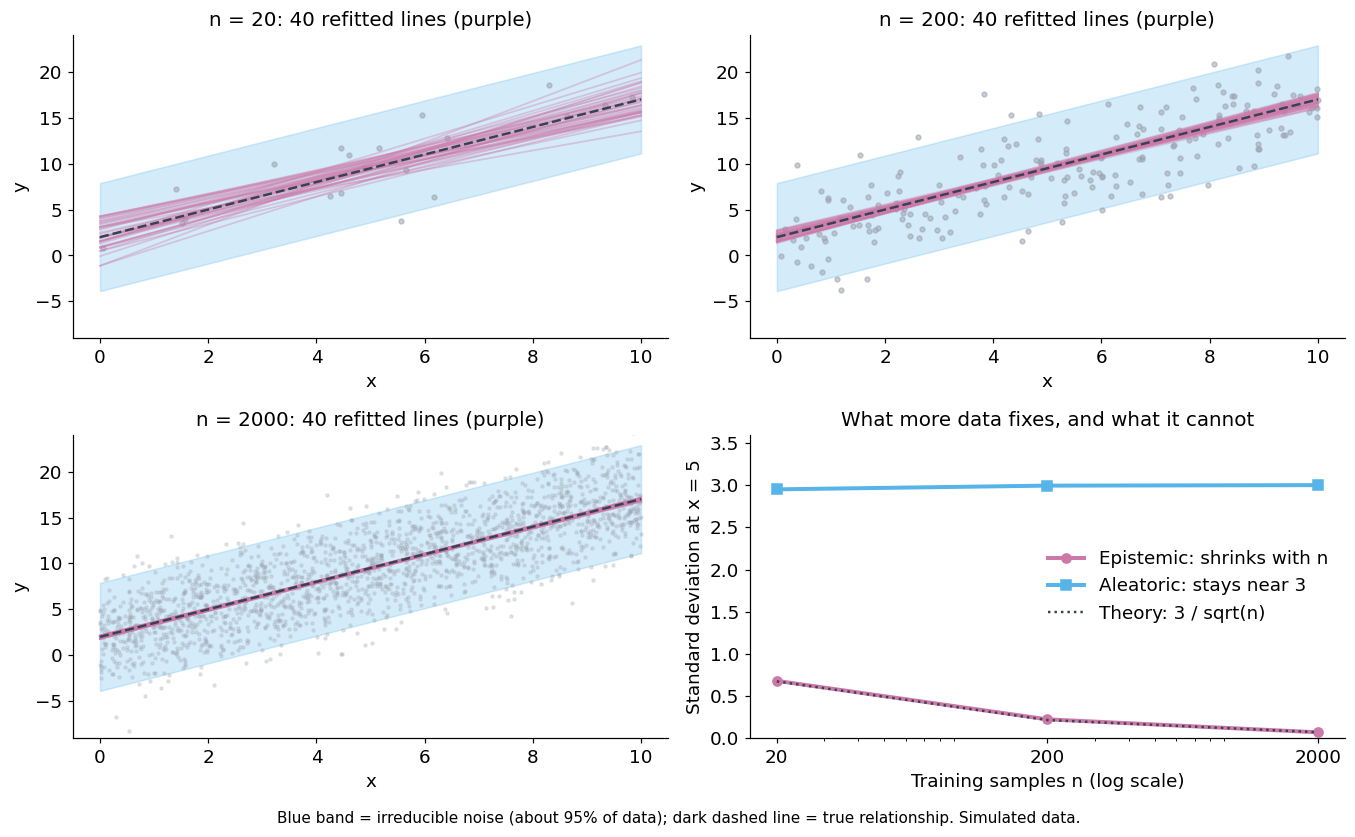

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12.5, 7.6))
xs = np.array([[0.0], [10.0]])
true_line = TRUE_A + TRUE_B * xs.ravel()

for ax, n in zip(axes.ravel()[:3], (20, 200, 2000)):
    x, y = draw(n)
    ax.scatter(x, y, s=10 if n < 2000 else 4, color=MISS, alpha=0.55 if n < 2000 else 0.25, zorder=1)
    for _ in range(40):                                   # 40 refits on fresh samples
        xi, yi = draw(n)
        m = LinearRegression().fit(xi, yi)
        ax.plot(xs.ravel(), m.predict(xs), color=EPIS, alpha=0.35, lw=1.2, zorder=3)
    ax.fill_between(xs.ravel(), true_line - 1.96 * SIGMA, true_line + 1.96 * SIGMA,
                    color=ALEA, alpha=0.25, zorder=0)
    ax.plot(xs.ravel(), true_line, color=CRISP, ls="--", lw=1.6, zorder=4)
    ax.set_ylim(-9, 24)
    ax.set_title(f"n = {n}: 40 refitted lines (purple)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

ax = axes[1, 1]
ax.plot(res["samples n"], res["epistemic sd (spread of predictions)"], "o-", color=EPIS, lw=2.6, label="Epistemic: shrinks with n")
ax.plot(res["samples n"], res["aleatoric sd (noise left in data)"], "s-", color=ALEA, lw=2.6, label="Aleatoric: stays near 3")
ax.plot(res["samples n"], res["theory: sigma / sqrt(n)"], ":", color=CRISP, lw=1.6, label="Theory: 3 / sqrt(n)")
ax.set_xscale("log")
ax.set_xticks([20, 200, 2000])
ax.set_xticklabels(["20", "200", "2000"])
ax.set_ylim(0, 3.6)
ax.set_xlabel("Training samples n (log scale)")
ax.set_ylabel("Standard deviation at x = 5")
ax.set_title("What more data fixes, and what it cannot")
ax.legend(frameon=False, loc="center right")

fig.text(0.5, 0.005, "Blue band = irreducible noise (about 95% of data); dark dashed line = true relationship. Simulated data.", ha="center", fontsize=10)
plt.tight_layout(rect=(0, 0.02, 1, 1))
plt.savefig("figures/fig_epistemic_aleatoric_simulation.png", dpi=200, bbox_inches="tight")
plt.show()

**Reading the figure.** With 20 samples the fitted lines fan out widely (large epistemic uncertainty). With 2,000 they almost coincide.
But the blue noise band never narrows: the standard deviation of the noise stays near 3 for every n. More data removes ignorance about the model, not randomness in the world.

## Appendix. Figures for the worked temperature example (slides 14, 15 and 18)

These cells only reproduce the pictures used on the slides; they are not part of the live demo.

Membership of 30 °C: warm = 0.4, hot = 0.6
Fuzzy 'hot' at 29.9 °C = 0.59; at 30.0 °C = 0.60


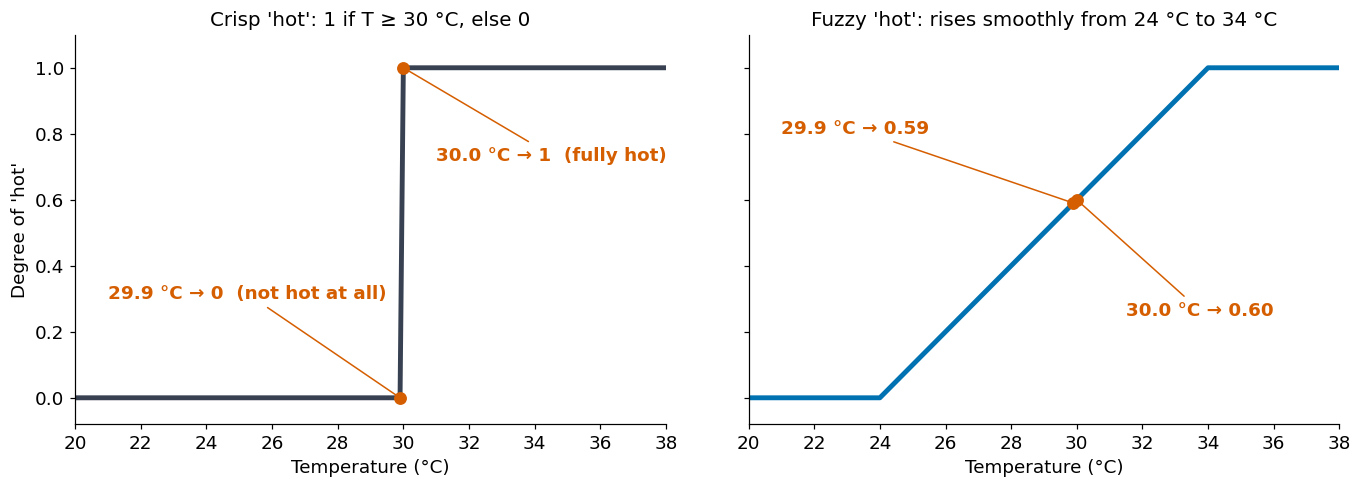

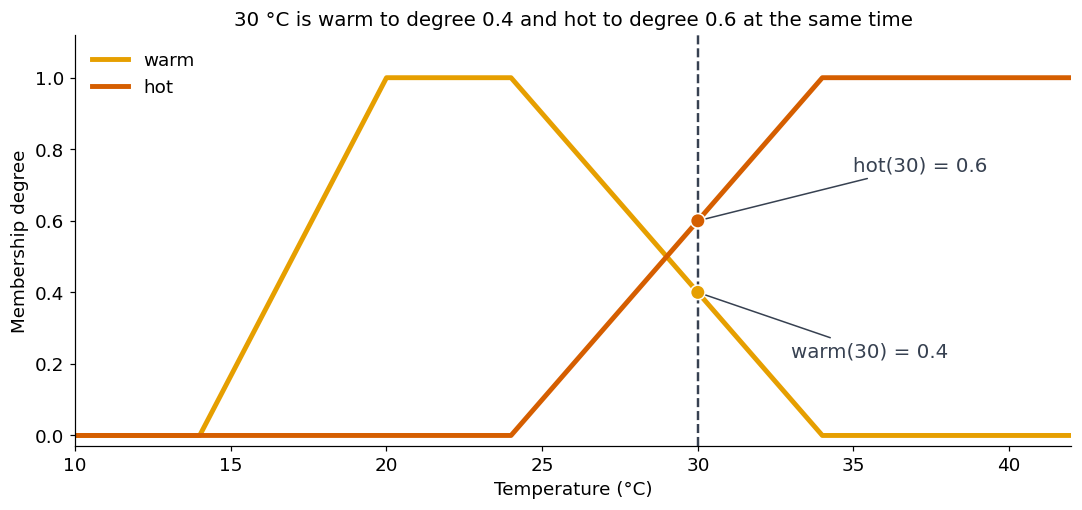

In [13]:
T = np.linspace(10, 45, 351)
warm = np.interp(T, [10, 14, 20, 24, 34, 45], [0, 0, 1, 1, 0, 0])   # rises 14-20, flat 20-24, falls 24-34
hot = np.clip((T - 24) / 10, 0, 1)                                  # rises 24-34
crisp_hot = (T >= 30).astype(float)                                 # crisp: hot starts at exactly 30 °C

warm_30 = float(np.interp(30, [10, 14, 20, 24, 34, 45], [0, 0, 1, 1, 0, 0]))
hot_30 = float(np.clip((30 - 24) / 10, 0, 1))
print(f"Membership of 30 °C: warm = {warm_30:.1f}, hot = {hot_30:.1f}")
print(f"Fuzzy 'hot' at 29.9 °C = {np.clip((29.9 - 24) / 10, 0, 1):.2f}; at 30.0 °C = {np.clip((30.0 - 24) / 10, 0, 1):.2f}")

# Figure 1: the threshold problem (crisp vs fuzzy 'hot')
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), sharey=True)
axes[0].plot(T, crisp_hot, color=CRISP, lw=3.2)
axes[1].plot(T, hot, color=FUZZY, lw=3.2)
axes[0].set_title("Crisp 'hot': 1 if T ≥ 30 °C, else 0")
axes[1].set_title("Fuzzy 'hot': rises smoothly from 24 °C to 34 °C")
for ax, f in [(axes[0], lambda t: float(t >= 30)), (axes[1], lambda t: float(np.clip((t - 24) / 10, 0, 1)))]:
    for t, dx in [(29.9, -4.6), (30.0, 1.0)]:
        ax.scatter([t], [f(t)], color=HOT, zorder=5, s=55)
    ax.set_xlim(20, 38)
    ax.set_ylim(-0.08, 1.1)
    ax.set_xlabel("Temperature (°C)")
axes[0].set_ylabel("Degree of 'hot'")
axes[0].annotate("29.9 °C → 0  (not hot at all)", (29.9, 0.0), xytext=(21.0, 0.3), color=HOT, fontsize=12, fontweight="bold",
                 arrowprops=dict(arrowstyle="-", color=HOT))
axes[0].annotate("30.0 °C → 1  (fully hot)", (30.0, 1.0), xytext=(31.0, 0.72), color=HOT, fontsize=12, fontweight="bold",
                 arrowprops=dict(arrowstyle="-", color=HOT))
axes[1].annotate("29.9 °C → 0.59", (29.9, 0.59), xytext=(21.0, 0.8), color=HOT, fontsize=12, fontweight="bold",
                 arrowprops=dict(arrowstyle="-", color=HOT))
axes[1].annotate("30.0 °C → 0.60", (30.0, 0.60), xytext=(31.5, 0.25), color=HOT, fontsize=12, fontweight="bold",
                 arrowprops=dict(arrowstyle="-", color=HOT))
plt.tight_layout()
plt.savefig("figures/fig_temperature_crisp_vs_fuzzy.png", dpi=200, bbox_inches="tight")
plt.show()

# Figure 2: 30 °C belongs to 'warm' and 'hot' at the same time
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(T, warm, color=WARM, lw=3.2, label="warm")
ax.plot(T, hot, color=HOT, lw=3.2, label="hot")
ax.axvline(30, color=CRISP, ls="--", lw=1.6)
ax.scatter([30, 30], [warm_30, hot_30], color=[WARM, HOT], s=90, zorder=5, edgecolor="white")
ax.annotate(f"warm({30}) = {warm_30:.1f}", (30, warm_30), xytext=(33.0, 0.22), fontsize=13, color=CRISP,
            arrowprops=dict(arrowstyle="-", color=CRISP))
ax.annotate(f"hot({30}) = {hot_30:.1f}", (30, hot_30), xytext=(35.0, 0.74), fontsize=13, color=CRISP,
            arrowprops=dict(arrowstyle="-", color=CRISP))
ax.set_xlim(10, 42)
ax.set_ylim(-0.03, 1.12)
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Membership degree")
ax.set_title("30 °C is warm to degree 0.4 and hot to degree 0.6 at the same time")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.savefig("figures/fig_warm_hot_at_30C.png", dpi=200, bbox_inches="tight")
plt.show()

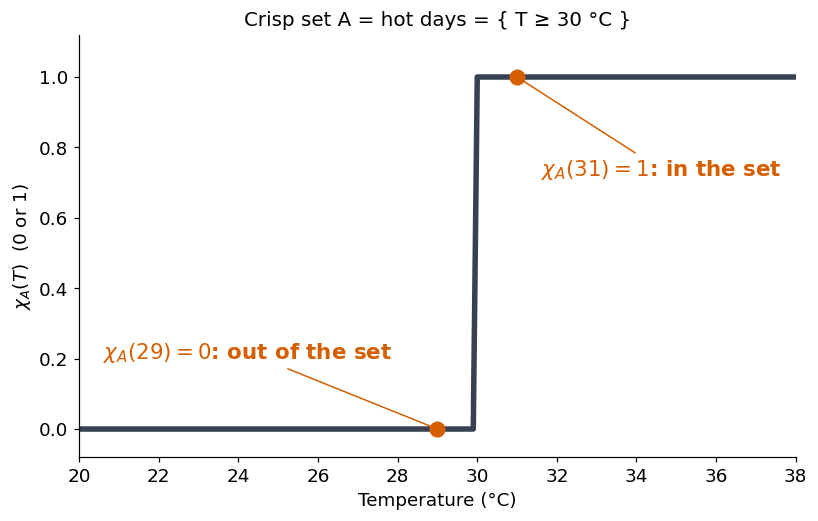

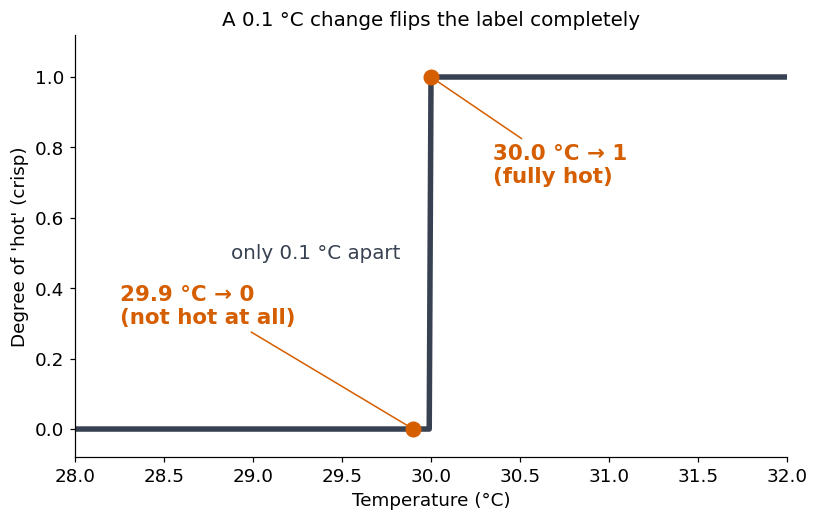

In [14]:
# Figures for slides 14 and 15: the crisp set and the threshold problem (zoomed)
fig, ax = plt.subplots(figsize=(7.6, 4.9))
ax.plot(T, crisp_hot, color=CRISP, lw=3.6)
for t, txt, xy in [(29, r"$\chi_A(29) = 0$: out of the set", (20.6, 0.2)),
                   (31, r"$\chi_A(31) = 1$: in the set", (31.6, 0.72))]:
    ax.scatter([t], [float(t >= 30)], color=HOT, s=90, zorder=5)
    ax.annotate(txt, (t, float(t >= 30)), xytext=xy, fontsize=14, color=HOT, fontweight="bold",
                arrowprops=dict(arrowstyle="-", color=HOT))
ax.set_xlim(20, 38)
ax.set_ylim(-0.08, 1.12)
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel(r"$\chi_A(T)$  (0 or 1)")
ax.set_title(r"Crisp set A = hot days = { T ≥ 30 °C }")
plt.tight_layout()
plt.savefig("figures/fig_characteristic_function.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7.6, 4.9))
tz = np.linspace(28, 32, 401)
ax.plot(tz, (tz >= 30).astype(float), color=CRISP, lw=3.6)
ax.scatter([29.9, 30.0], [0.0, 1.0], color=HOT, s=90, zorder=5)
ax.annotate("29.9 °C → 0\n(not hot at all)", (29.9, 0.0), xytext=(28.25, 0.3), fontsize=14, color=HOT,
            fontweight="bold", arrowprops=dict(arrowstyle="-", color=HOT))
ax.annotate("30.0 °C → 1\n(fully hot)", (30.0, 1.0), xytext=(30.35, 0.7), fontsize=14, color=HOT,
            fontweight="bold", arrowprops=dict(arrowstyle="-", color=HOT))
ax.text(29.83, 0.5, "only 0.1 °C apart", fontsize=13, color=CRISP, ha="right", va="center")
ax.set_xlim(28, 32)
ax.set_ylim(-0.08, 1.12)
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Degree of 'hot' (crisp)")
ax.set_title("A 0.1 °C change flips the label completely")
plt.tight_layout()
plt.savefig("figures/fig_threshold_problem.png", dpi=200, bbox_inches="tight")
plt.show()

## Take-away

1. A table with no `NaN` can still hide missing data. Ask what values are physically possible.
2. A crisp threshold turns a tiny change (BMI 29.9 to 30.1) into a full flip; a membership function changes gradually.
3. More data shrinks epistemic uncertainty; it cannot remove aleatoric noise. A model that must say "I am not sure" needs to know which one it is facing.

*Figures are saved in the `figures/` folder (in Colab: the folder icon in the left sidebar).*